# EDA Bolivia - Objetivo A (Reduccion de Falsos Positivos)

Este notebook analiza el dataset de Bolivia con foco en el Objetivo A: reducir falsos positivos manteniendo una alta deteccion de fraude.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)

## 1) Carga y validacion basica

In [2]:
candidate_paths = [
    Path('../data/bolivia_dataset.csv'),
    Path('data/bolivia_dataset.csv'),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('No se encontro bolivia_dataset.csv en rutas esperadas.')

df = pd.read_csv(data_path, sep=';')
print(f'Ruta usada: {data_path.resolve()}')
print(f'Shape: {df.shape}')
print(f'Columnas: {len(df.columns)}')
df.head(3)

Ruta usada: C:\Users\josue\uvg\Semestre 9\Security DS\federated-banking-fraud\data\bolivia_dataset.csv
Shape: (100003, 66)
Columnas: 66


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE48_additional_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,e253ee7d060689e75077b0c7d85d995bf4ba104a7a931e...,100,5.312700e+15,0,39379,345082,101000151,87630970.0,947249,200151,1231,2901,101.0,5651,826,72,1.0,0,14484680068,531270******3773=2901201,TEBBJIQJPQP9,17P76V,0,BO-23325,M74178102540833,LEVIS STORE LONDON GB,NaN,NaN,826,68,68,N,NaN,N,NaN,1.448468e+10,POS-ATTENDED,0.0,BO-VIP,1.448468e+10,ACC774404459020,NaN,07200N,3450.82,393.79,GBP,500.12,True,8717.0,20,Tue,True,Approved,2012.51,TARIJA,False
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,9de2ffd889d660bc1d350aff8143484eaab5246c0c3f31...,100,4.212500e+15,0,1310264,1310264,101000355,10000000.0,7687,200355,1231,2907,101.0,4511,68,81,2.0,59,14484680068,421250******5552=2907201,115BVLO5H5F0,48D1XM,0,BO-34705,M95802681578714,IBERIA LAPAZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC620405269742,NaN,08159N,13102.64,13102.64,BOB,1898.93,False,4.9,20,Tue,True,Approved,1096.46,LAPAZ,False
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,14d38149e4bcdeffed96229129ba6d359b477780d24ba0...,100,5.312700e+15,0,241394,241394,101000410,10000000.0,979481,200410,1231,2610,101.0,5732,68,81,2.0,59,14484680068,531270******6104=2610201,NUKM3XFSZVJX,PFIGFD,0,BO-31334,M28333044130009,AMAZON ELECTRO SANTACRUZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC606260684104,NaN,08159N,2413.94,2413.94,BOB,349.85,False,4.4,20,Tue,True,Approved,1528.37,SANTACRUZ,False


In [3]:
target_candidates = [
    c for c in df.columns if c.lower() in ['fraud', 'isfraud', 'is_fraud', 'label', 'class', 'target', 'fraude']
]
target_col = target_candidates[0] if target_candidates else df.columns[-1]

print(f'Variable objetivo detectada: {target_col}')
print(f'Tipo: {df[target_col].dtype}')

if df[target_col].dtype != bool:
    # Normalizacion defensiva por si el target viniera como string/int
    map_bool = {'true': True, 'false': False, 1: True, 0: False, '1': True, '0': False}
    df[target_col] = df[target_col].map(lambda x: map_bool.get(str(x).lower(), x))

counts = df[target_col].value_counts(dropna=False)
pcts = df[target_col].value_counts(normalize=True, dropna=False) * 100
pd.DataFrame({'conteo': counts, 'porcentaje': pcts.round(4)})

Variable objetivo detectada: is_fraud
Tipo: bool


,conteo,porcentaje
is_fraud,,
False,95084,95.0811
True,4919,4.9189


## 2) Calidad de datos y desbalance

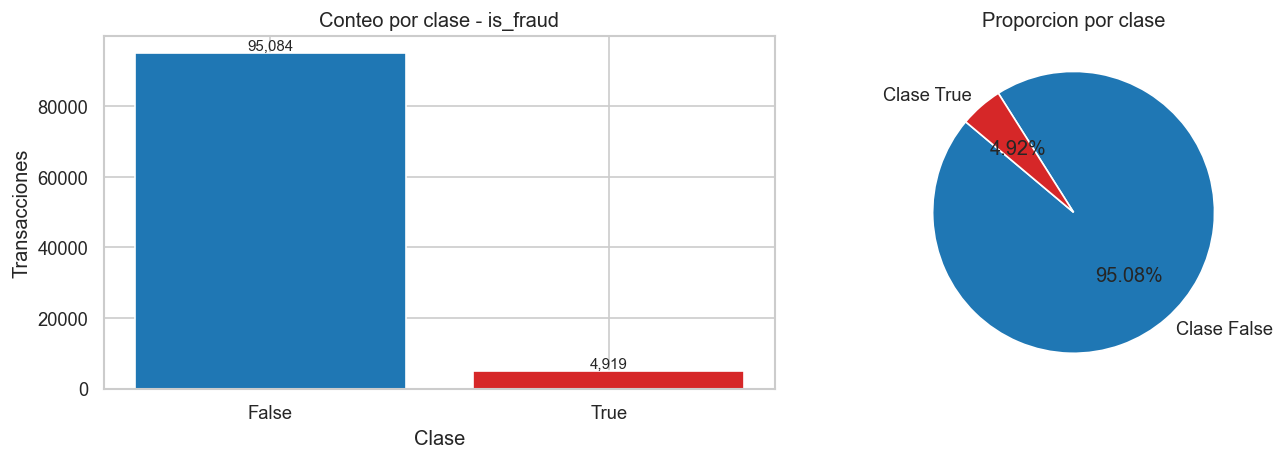

Imbalance ratio: 19.33:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#1f77b4', '#d62728']

axes[0].bar(counts.index.astype(str), counts.values, color=colors[:len(counts)])
axes[0].set_title(f'Conteo por clase - {target_col}')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Transacciones')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + counts.max() * 0.01, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    counts.values,
    labels=[f'Clase {c}' for c in counts.index],
    autopct='%1.2f%%',
    colors=colors[:len(counts)],
    startangle=140
)
axes[1].set_title('Proporcion por clase')
plt.tight_layout()
plt.show()

majority = counts.max()
minority = counts.min()
imbalance_ratio = majority / minority
print(f'Imbalance ratio: {imbalance_ratio:.2f}:1')

,pct_nulos
DE48_additional_data,100.000000
DE103_account_id_2,100.000000
DE54_additional_amounts,100.000000
DE56_original_data,100.000000
DE44_additional_response_data,96.733098
DE38_authorization_code,3.266902
DE100_receiving_institution_id,1.049969
client_segment,1.045969
DE63_network_specific,1.044969
card_brand,1.041969


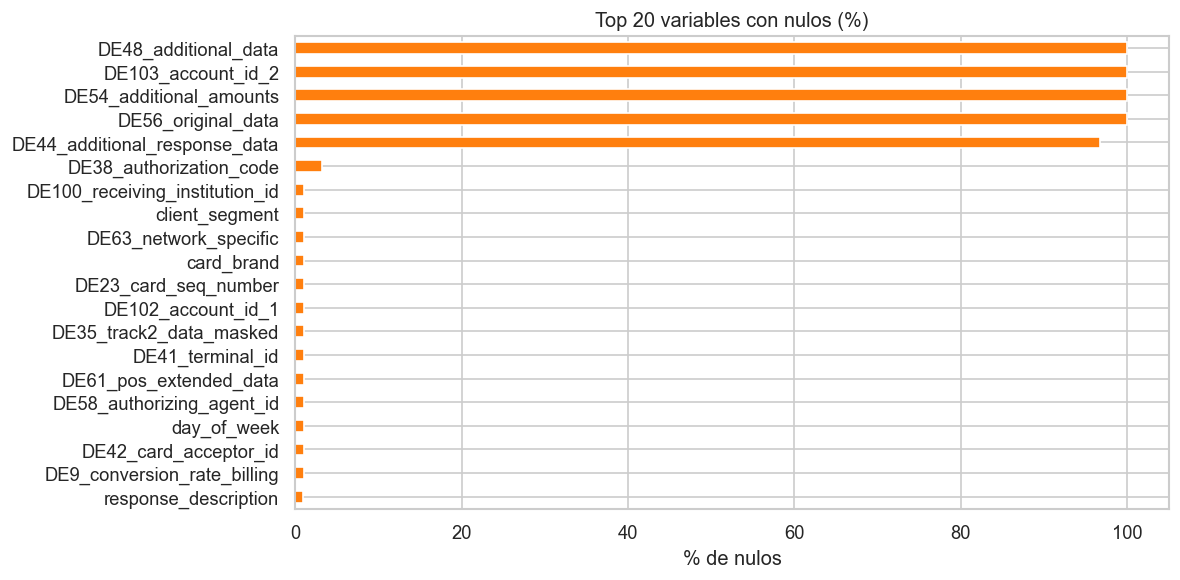

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print('No hay valores nulos.')
else:
    display(missing_nonzero.head(20).to_frame('pct_nulos'))
    plt.figure(figsize=(10, 5))
    missing_nonzero.head(20).sort_values().plot(kind='barh', color='#ff7f0e')
    plt.title('Top 20 variables con nulos (%)')
    plt.xlabel('% de nulos')
    plt.tight_layout()
    plt.show()

## 3) Clasificacion de variables (utiles vs riesgo de leakage/ID)

In [6]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

import re
id_regex = re.compile(r'(^id$|_id$|_id_|^id_|hash|(^|_)pan(_|$)|(^|_)stan(_|$)|reference|track2|authorization_code)', re.IGNORECASE)
high_cardinality_cols = [
    c for c in df.columns
    if df[c].nunique(dropna=False) / len(df) > 0.90
]
name_id_cols = [
    c for c in df.columns
    if id_regex.search(c)
]

leakage_candidates = [
    c for c in ['DE39_response_code', 'approved', 'response_description']
    if c in df.columns
]

risk_cols = sorted(set(constant_cols + high_cardinality_cols + name_id_cols + leakage_candidates))

print(f'Constantes ({len(constant_cols)}): {constant_cols}')
print(f'High cardinality >90% ({len(high_cardinality_cols)}): {high_cardinality_cols[:15]}')
print(f'Patron ID ({len(name_id_cols)}): {name_id_cols}')
print(f'Posibles leakage ({len(leakage_candidates)}): {leakage_candidates}')
print(f'Total variables de riesgo para modelado directo: {len(risk_cols)}')

Constantes (12): ['bank_code', 'bank_name', 'bank_country', 'bank_tier', 'MTI', 'DE32_acquiring_institution_id', 'DE48_additional_data', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2']
High cardinality >90% (5): ['transaction_id', 'DE7_transmission_datetime', 'DE11_STAN', 'DE37_retrieval_reference_number', 'DE38_authorization_code']
Patron ID (16): ['transaction_id', 'client_id', 'pan_masked', 'pan_hash', 'DE2_PAN', 'DE11_STAN', 'DE32_acquiring_institution_id', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE58_authorizing_agent_id', 'DE100_receiving_institution_id', 'DE102_account_id_1', 'DE103_account_id_2']
Posibles leakage (3): ['DE39_response_code', 'approved', 'response_description']
Total variables de riesgo para modelado directo: 30


In [7]:
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols_all if c not in risk_cols and c != target_col]

categorical_candidates = [
    c for c in df.columns
    if c != target_col and c not in risk_cols and (df[c].dtype == 'object' or df[c].nunique() < 20)
]

print(f'Numericas totales: {len(numeric_cols_all)}')
print(f'Numericas explorables sin riesgo: {len(numeric_cols)}')
print(f'Categoricas/codigos explorables: {len(categorical_candidates)}')
print('Ejemplo numericas:', numeric_cols[:12])
print('Ejemplo categoricas:', categorical_candidates[:12])

Numericas totales: 35
Numericas explorables sin riesgo: 21
Categoricas/codigos explorables: 21
Ejemplo numericas: ['DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE9_conversion_rate_billing', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number']
Ejemplo categoricas: ['client_segment', 'channel', 'card_brand', 'DE3_processing_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE43_card_acceptor_name_location', 'DE44_additional_response_data', 'DE49_currency_code_transaction', 'DE52_pin_data_present']


## 4) Analisis de variables numericas

In [8]:
summary_rows = []
for c in numeric_cols:
    legit = df.loc[df[target_col] == False, c].dropna()
    fraud = df.loc[df[target_col] == True, c].dropna()
    if len(legit) == 0 or len(fraud) == 0:
        continue

    m0, m1 = legit.mean(), fraud.mean()
    s0, s1 = legit.std(ddof=1), fraud.std(ddof=1)
    pooled = np.sqrt(((len(legit)-1)*(s0**2) + (len(fraud)-1)*(s1**2)) / (len(legit)+len(fraud)-2))
    cohen_d = 0 if pooled == 0 else (m1 - m0) / pooled

    summary_rows.append({
        'feature': c,
        'mean_legit': m0,
        'mean_fraud': m1,
        'median_legit': legit.median(),
        'median_fraud': fraud.median(),
        'pct_diff_mean': np.nan if m0 == 0 else ((m1 - m0) / abs(m0)) * 100,
        'cohen_d': cohen_d
    })

num_summary = pd.DataFrame(summary_rows).sort_values('cohen_d', key=lambda s: s.abs(), ascending=False)
display(num_summary.head(20).round(4))

,feature,mean_legit,mean_fraud,median_legit,median_fraud,pct_diff_mean,cohen_d
15,amount_local,2.731799e+03,7.599129e+03,1.324670e+03,5441.76,178.1731,1.2202
2,DE6_amount_cardholder_billing,2.731799e+05,7.599129e+05,1.324670e+05,544176.00,178.1731,1.2202
17,amount_usd,3.959129e+02,1.101323e+03,1.919850e+02,788.66,178.1730,1.2202
14,DE61_pos_extended_data,2.685010e+01,4.466390e+01,1.000000e+00,59.00,66.3453,0.6176
12,DE25_pos_condition_code,2.684660e+01,4.464420e+01,1.000000e+00,59.00,66.2939,0.6171
10,DE22_pos_entry_mode,6.277040e+01,7.321690e+01,7.200000e+01,81.00,16.6424,0.4872
16,amount_tx_currency,1.173115e+04,6.330103e+04,1.078140e+03,2365.21,439.5979,0.4486
1,DE4_amount_transaction,1.173115e+06,6.330103e+06,1.078140e+05,236521.00,439.5979,0.4486
13,DE49_currency_code_transaction,2.284969e+02,3.526465e+02,6.800000e+01,68.00,54.3332,0.3801
18,distance_from_home_km,1.720966e+03,2.894743e+03,2.070000e+01,782.00,68.2045,0.3657


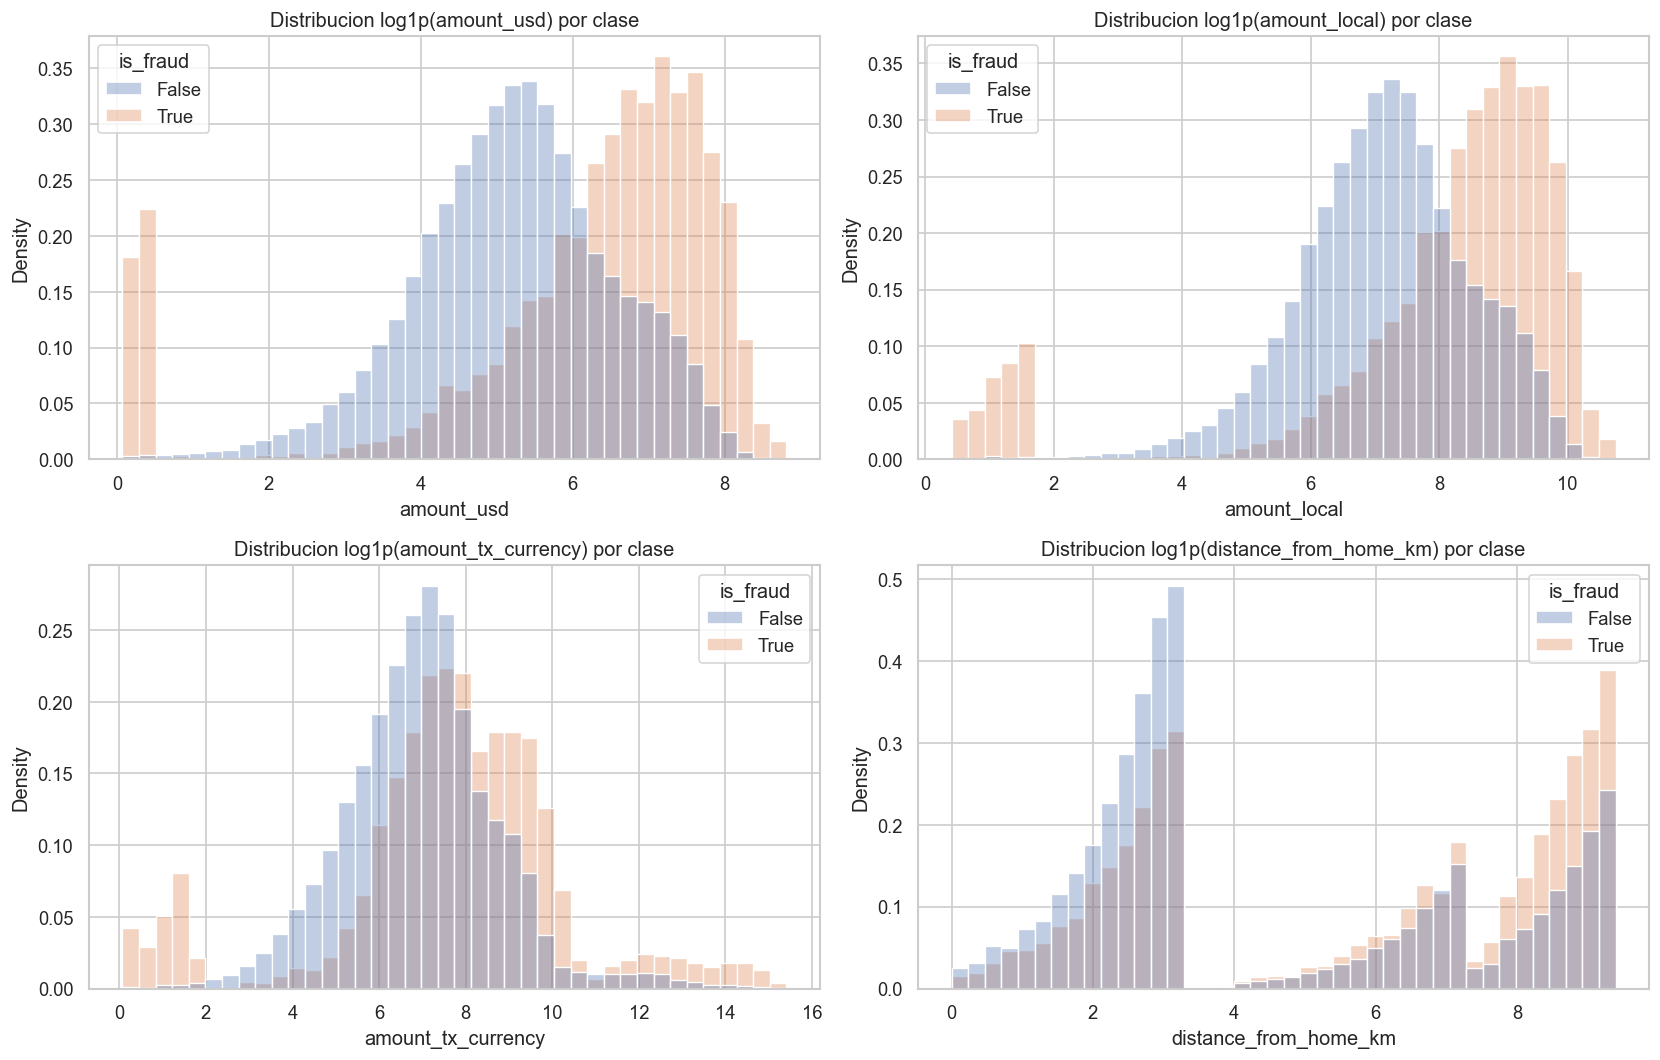

In [9]:
key_amount_features = [c for c in ['amount_usd', 'amount_local', 'amount_tx_currency', 'distance_from_home_km'] if c in df.columns]

if key_amount_features:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for i, col in enumerate(key_amount_features[:4]):
        plot_df = df[[col, target_col]].dropna().copy()
        plot_df[col] = np.log1p(plot_df[col])
        sns.histplot(
            data=plot_df,
            x=col,
            hue=target_col,
            bins=40,
            stat='density',
            common_norm=False,
            alpha=0.35,
            ax=axes[i]
        )
        axes[i].set_title(f'Distribucion log1p({col}) por clase')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron variables de monto esperadas para histograma.')

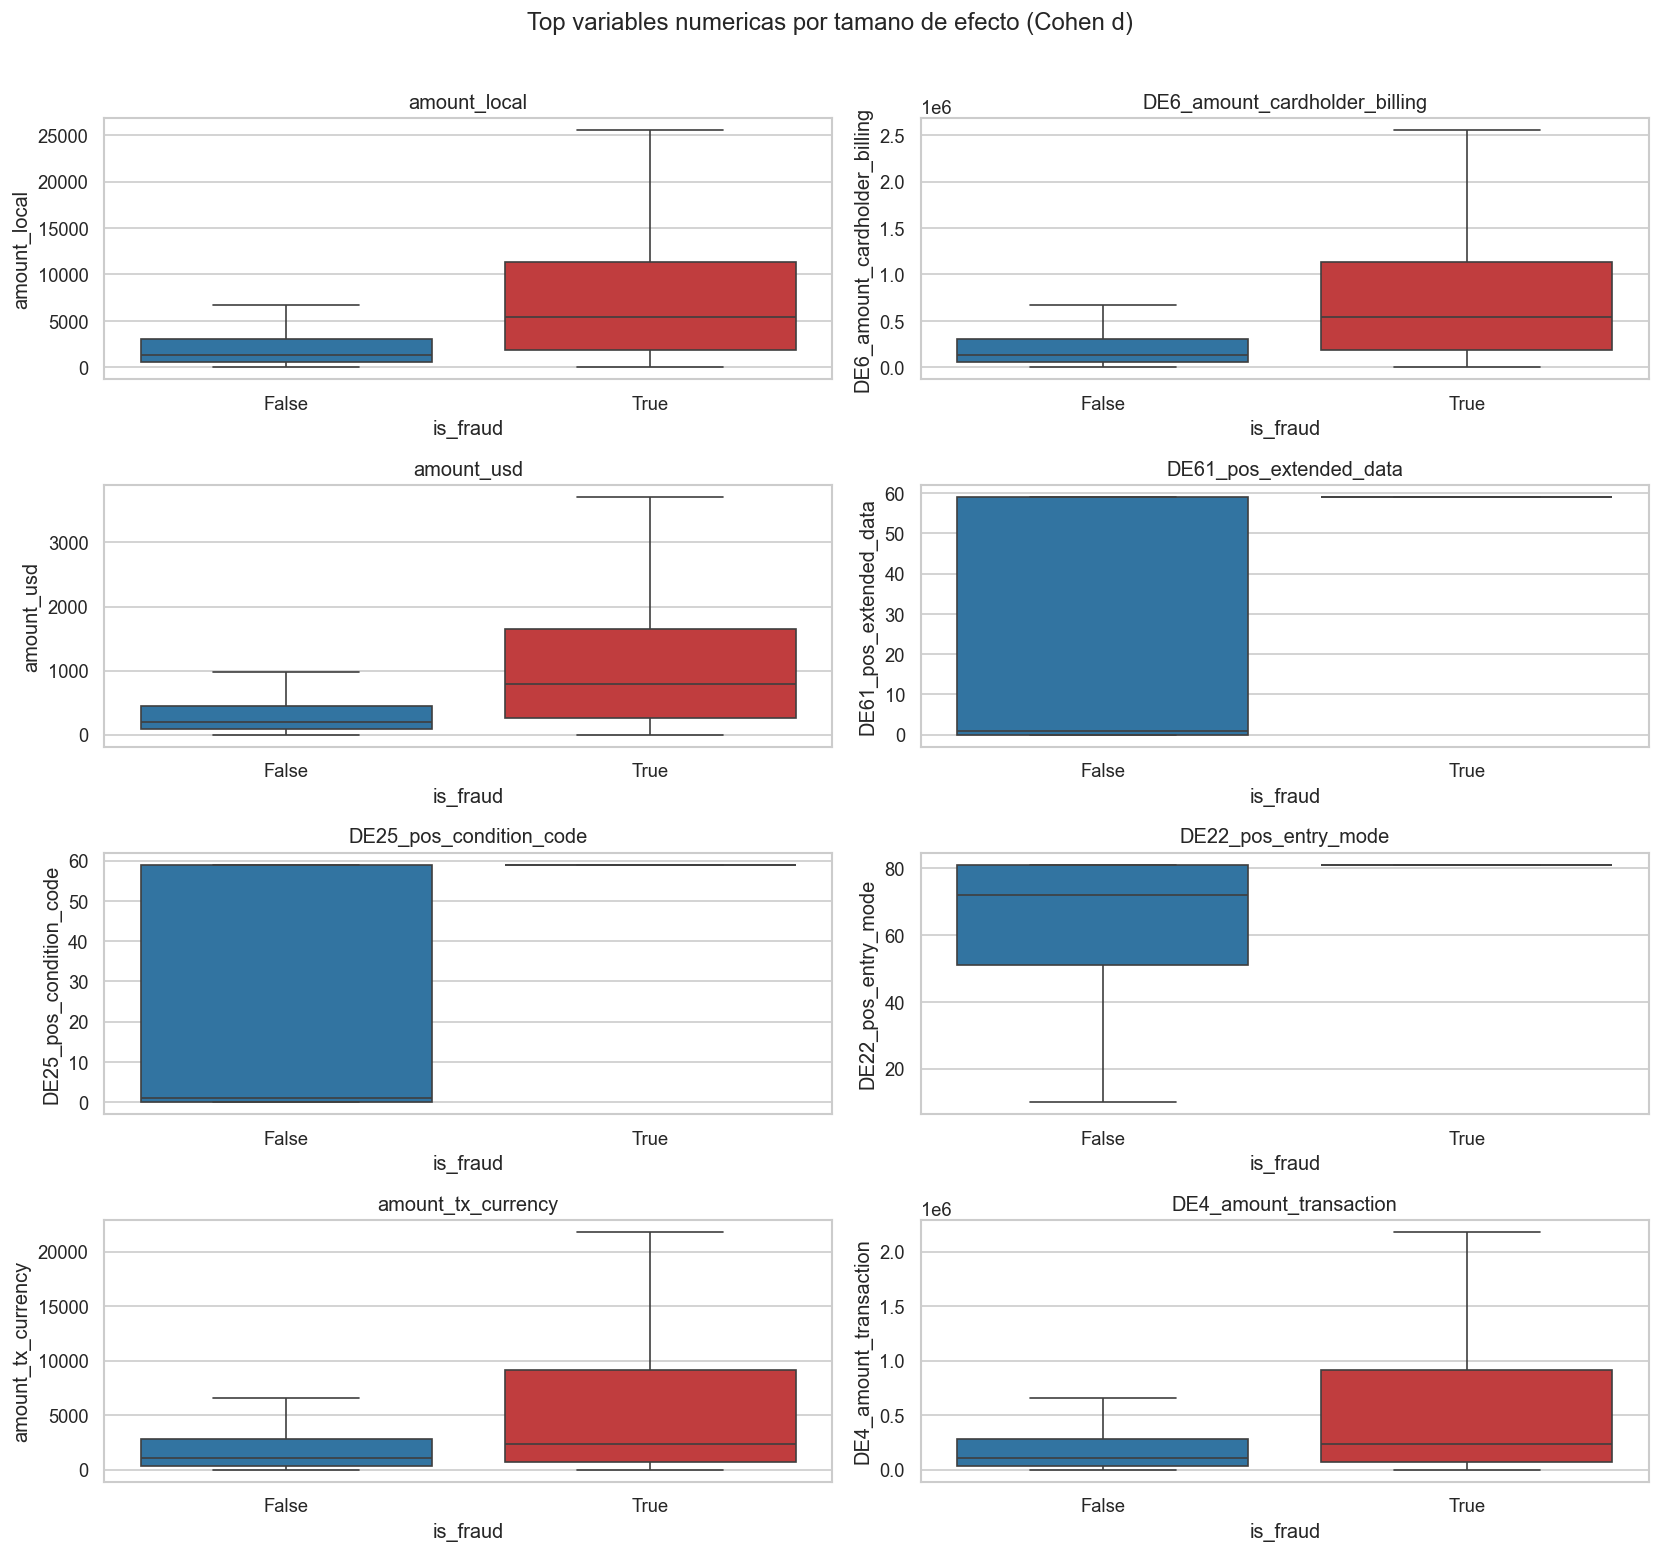

In [10]:
top_box = num_summary.head(8)['feature'].tolist() if not num_summary.empty else []

if top_box:
    rows = int(np.ceil(len(top_box) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 3.2))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(top_box):
        sns.boxplot(
            data=df[[col, target_col]].dropna(),
            x=target_col,
            y=col,
            palette=['#1f77b4', '#d62728'],
            showfliers=False,
            ax=axes[i]
        )
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Top variables numericas por tamano de efecto (Cohen d)', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No hay variables numericas para boxplots.')

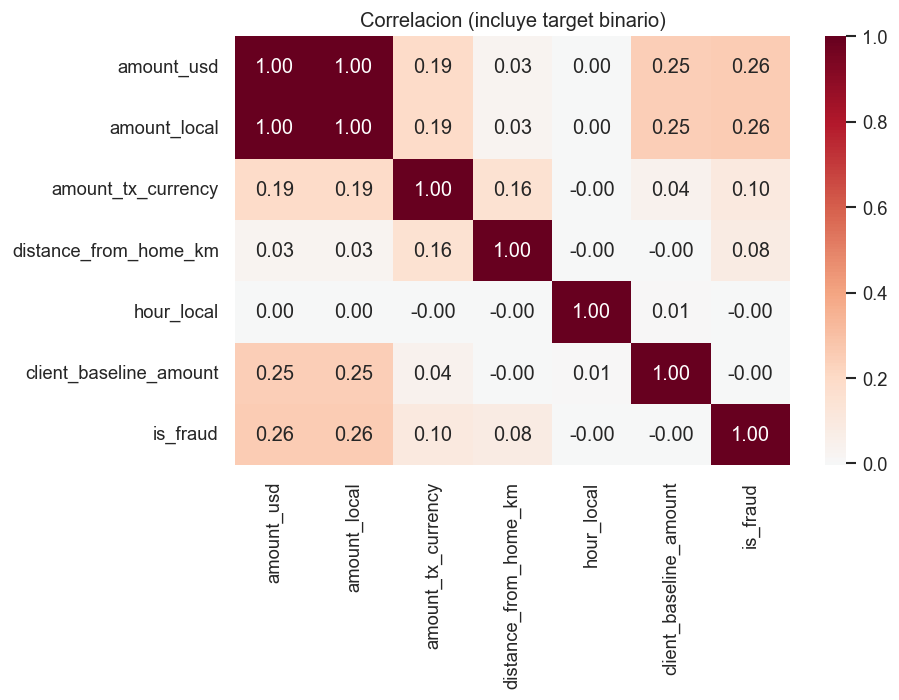

In [11]:
corr_cols = [c for c in ['amount_usd', 'amount_local', 'amount_tx_currency', 'distance_from_home_km', 'hour_local', 'client_baseline_amount'] if c in df.columns]

if corr_cols:
    corr_df = df[corr_cols + [target_col]].copy()
    corr_df[target_col] = corr_df[target_col].astype(int)
    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
    plt.title('Correlacion (incluye target binario)')
    plt.tight_layout()
    plt.show()

## 5) Analisis de variables categoricas y codigos

In [12]:
interesting_cat = [
    c for c in [
        'channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code',
        'is_international', 'day_of_week', 'currency_tx_alpha', 'client_segment'
    ] if c in df.columns and c not in risk_cols
]

cat_tables = {}
for col in interesting_cat:
    tmp = (
        df.groupby(col, dropna=False)[target_col]
        .agg(total='count', fraud_rate='mean')
        .sort_values(['fraud_rate', 'total'], ascending=[False, False])
    )
    tmp['fraud_rate_pct'] = tmp['fraud_rate'] * 100
    tmp['share_pct'] = tmp['total'] / len(df) * 100
    cat_tables[col] = tmp

for col, t in cat_tables.items():
    print(f'\n{col}')
    display(t.head(10).round(4))


channel


,total,fraud_rate,fraud_rate_pct,share_pct
channel,,,,
ECOM,46312,0.0802,8.0217,46.3106
ATM,9725,0.0284,2.8380,9.7247
POS,39128,0.0224,2.2414,39.1268
MOTO,4838,0.0105,1.0542,4.8379



card_brand


,total,fraud_rate,fraud_rate_pct,share_pct
card_brand,,,,
MASTERCARD,32812,0.0513,5.1323,32.811
VISA,66149,0.0482,4.8164,66.147
NaN,1042,0.0470,4.7025,1.042



DE22_pos_entry_mode


...

,total,fraud_rate,fraud_rate_pct,share_pct
day_of_week,,,,
NaN,1005,0.0587,5.8706,1.0050
Wed,14450,0.0547,5.4740,14.4496
Sat,14447,0.0543,5.4267,14.4466
Fri,14203,0.0512,5.1186,14.2026
Mon,13836,0.0477,4.7702,13.8356
Thu,14281,0.0473,4.7266,14.2806
Tue,13805,0.0467,4.6722,13.8046
Sun,13976,0.0414,4.1357,13.9756



currency_tx_alpha


,total,fraud_rate,fraud_rate_pct,share_pct
currency_tx_alpha,,,,
JPY,2444,0.0896,8.9607,2.4439
CLP,2313,0.0873,8.7332,2.3129
EUR,9302,0.0849,8.4928,9.3017
USD,7024,0.0831,8.3144,7.0238
GBP,2358,0.0797,7.9729,2.3579
BOB,76562,0.0383,3.8348,76.5597



client_segment


,total,fraud_rate,fraud_rate_pct,share_pct
client_segment,,,,
NaN,1046,0.0545,5.4493,1.0460
PRIVATE,44238,0.0517,5.1675,44.2367
PLATINUM,20607,0.0492,4.9207,20.6064
BLACK,28908,0.0463,4.6319,28.9071
INFINITE,5204,0.0429,4.2852,5.2038


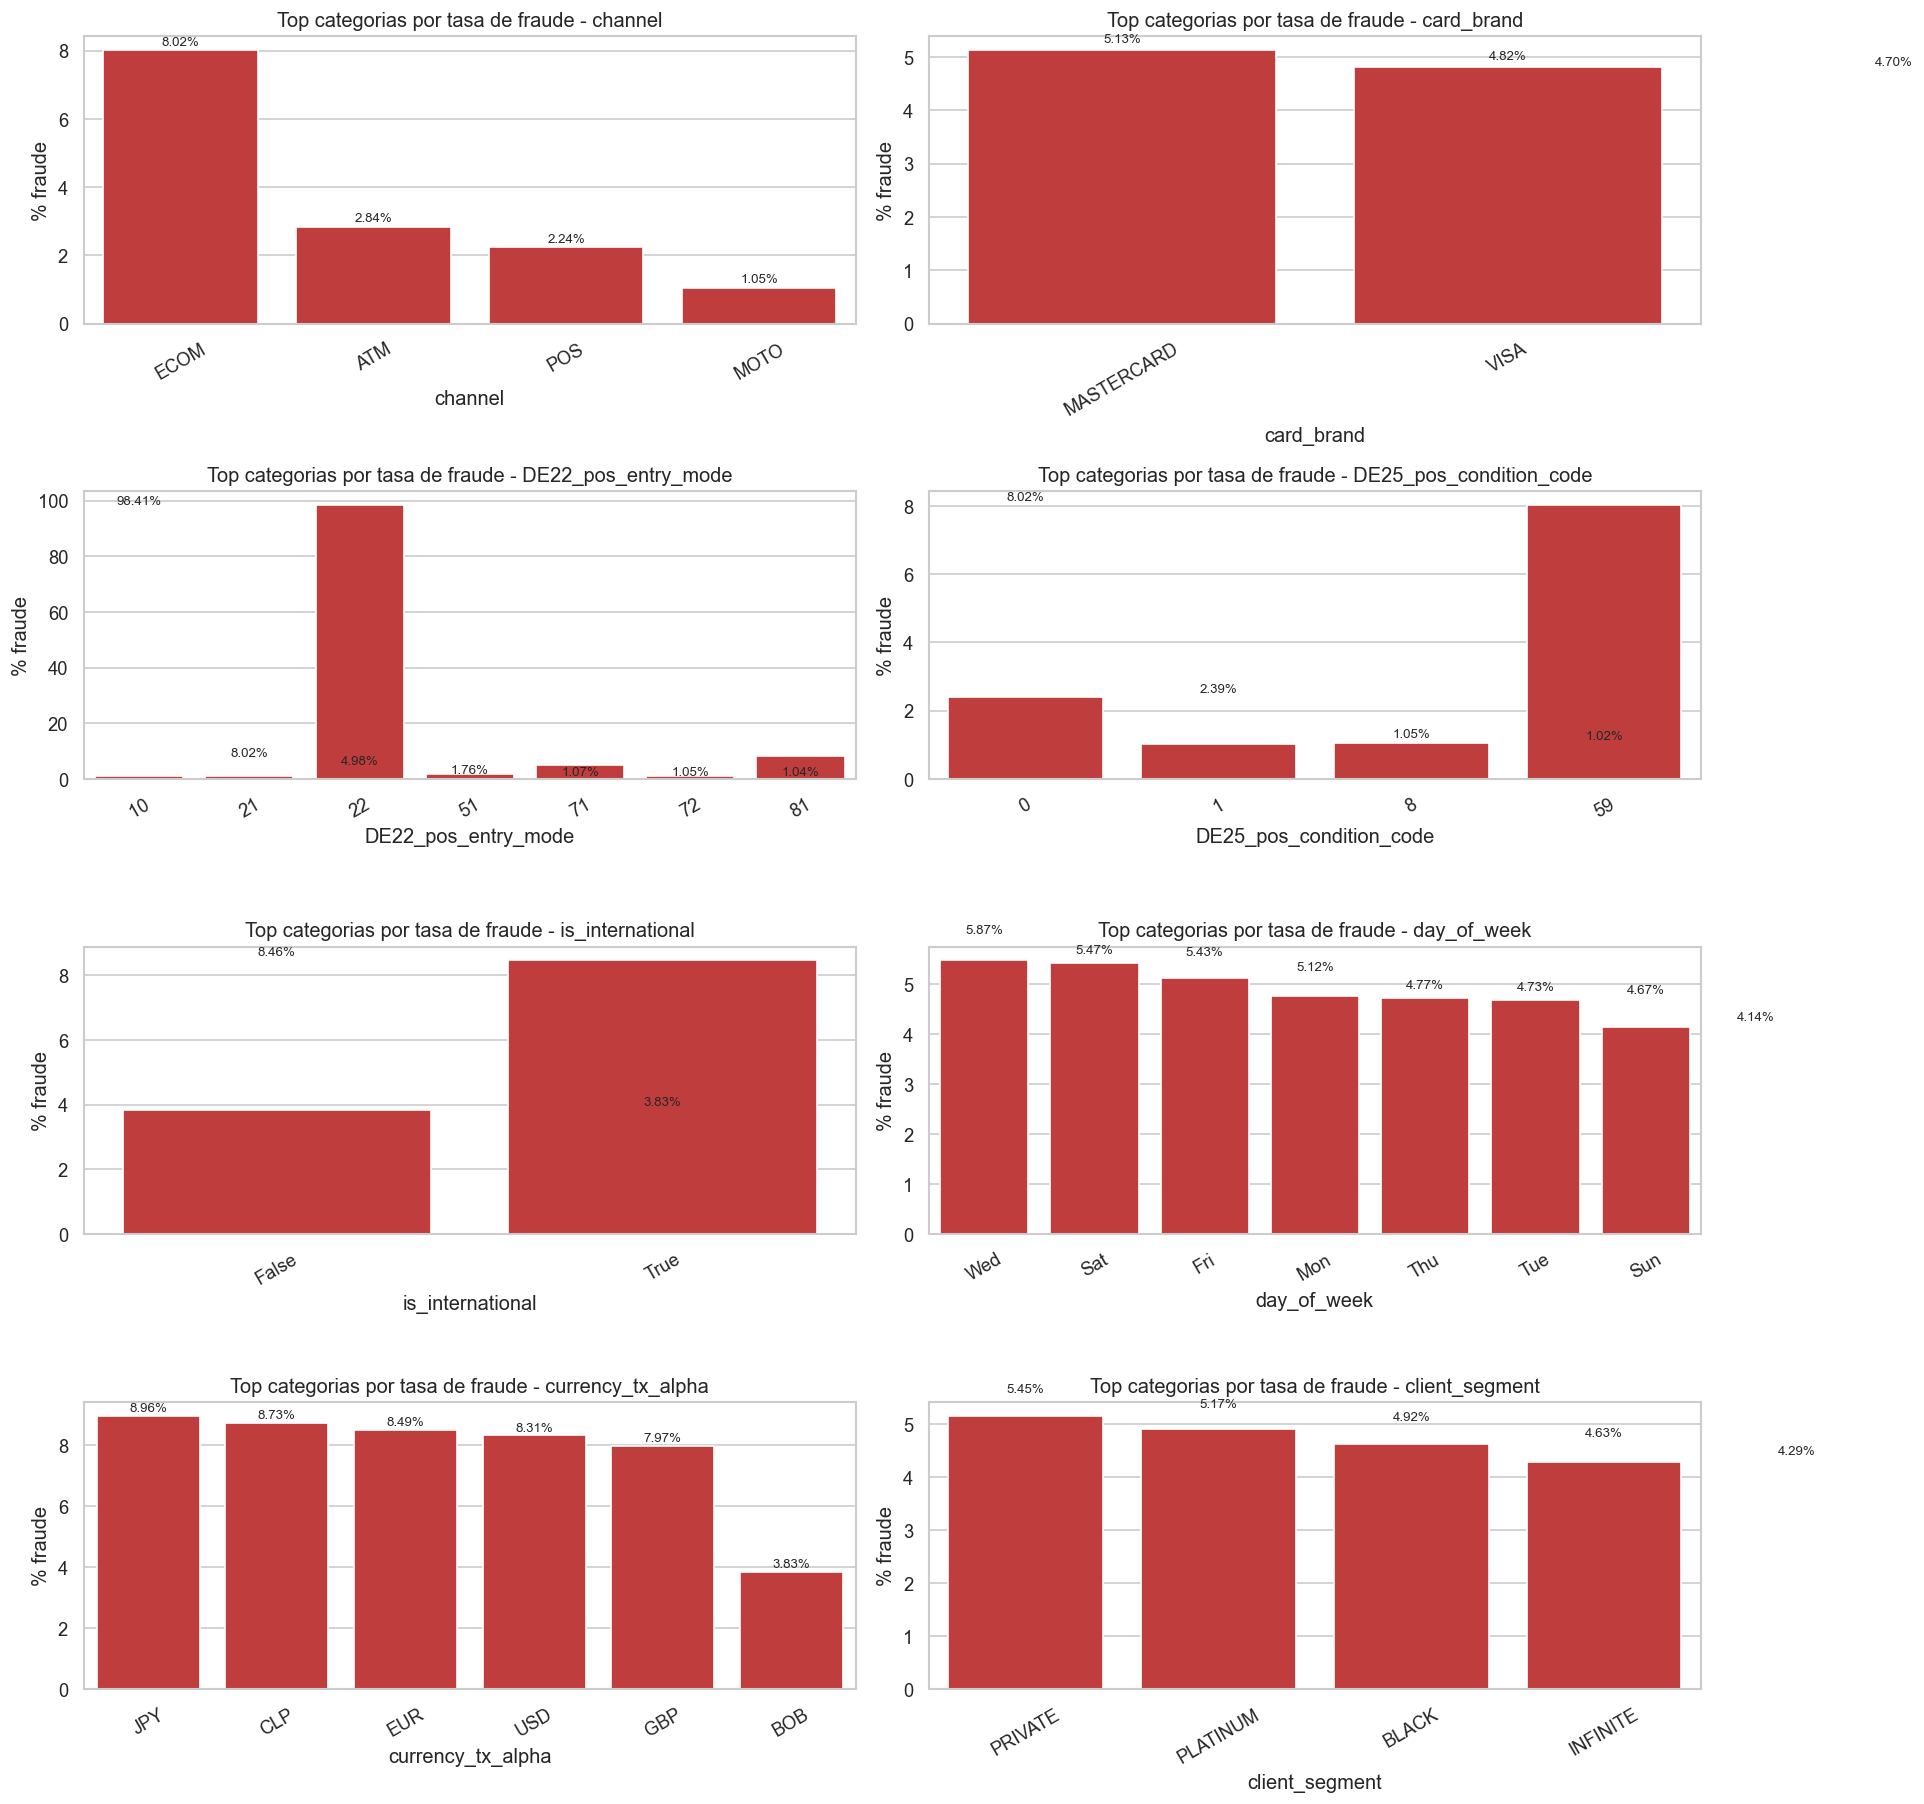

In [13]:
if interesting_cat:
    rows = int(np.ceil(len(interesting_cat) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 3.8))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(interesting_cat):
        t = cat_tables[col].reset_index().copy()
        t = t.sort_values('fraud_rate_pct', ascending=False).head(8)
        sns.barplot(data=t, x=col, y='fraud_rate_pct', color='#d62728', ax=axes[i])
        axes[i].set_title(f'Top categorias por tasa de fraude - {col}')
        axes[i].set_ylabel('% fraude')
        axes[i].tick_params(axis='x', rotation=30)

        for j, v in enumerate(t['fraud_rate_pct']):
            axes[i].text(j, v + 0.15, f'{v:.2f}%', ha='center', fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## 6) Temporalidad del fraude

,month_parsed,total,frauds,fraud_rate_pct
0,0,982,53,5.3971
1,1,16658,824,4.9466
2,2,15467,760,4.9137
3,3,16968,881,5.1921
4,4,16404,813,4.9561
5,5,17054,841,4.9314
6,6,16470,747,4.5355


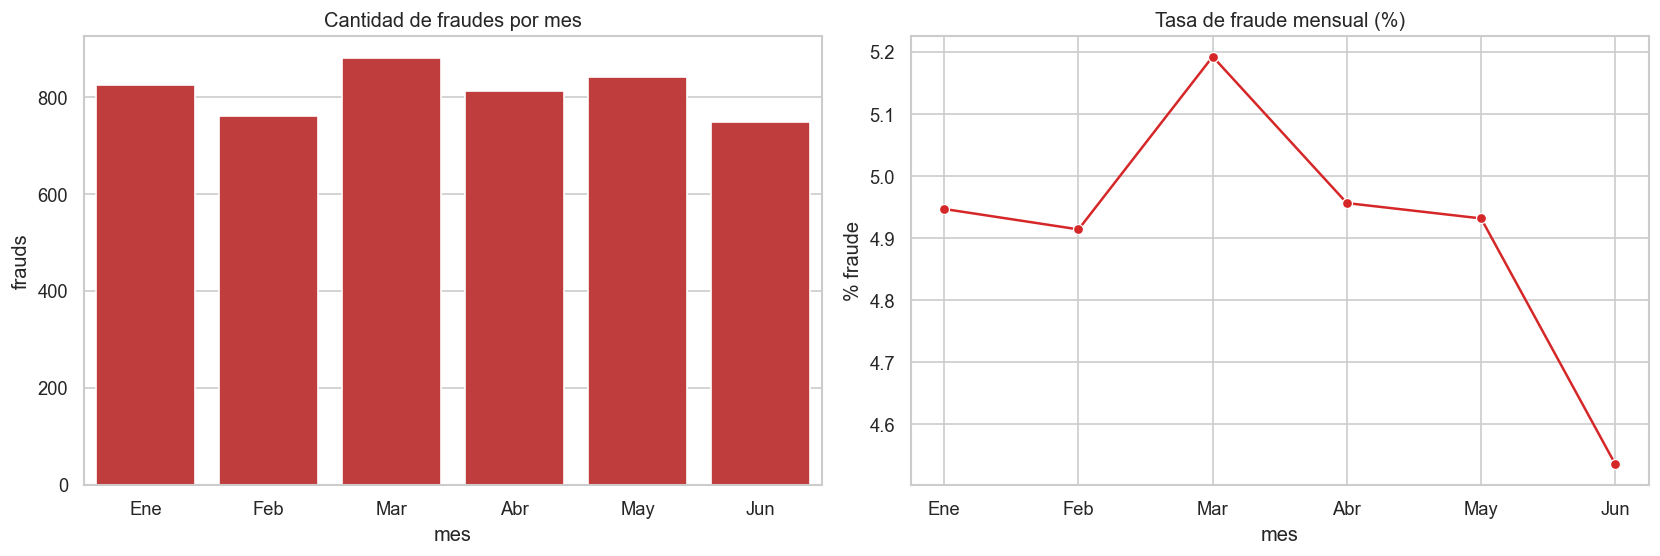

In [14]:
if 'DE15_settlement_date' in df.columns:
    temp = df.copy()
    temp['DE15_settlement_date_clean'] = temp['DE15_settlement_date'].fillna(0).astype(int)
    temp['month_parsed'] = temp['DE15_settlement_date_clean'].astype(str).str.zfill(4).str[:2].astype(int)

    monthly = (
        temp.groupby('month_parsed')[target_col]
        .agg(total='count', frauds='sum')
        .reset_index()
    )
    monthly['fraud_rate_pct'] = monthly['frauds'] / monthly['total'] * 100

    display(monthly.round(4))

    monthly_plot = monthly[monthly['month_parsed'].between(1, 12)].copy()
    month_names = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
    monthly_plot['mes'] = monthly_plot['month_parsed'].map(month_names).fillna(monthly_plot['month_parsed'].astype(str))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    sns.barplot(data=monthly_plot, x='mes', y='frauds', color='#d62728', ax=axes[0])
    axes[0].set_title('Cantidad de fraudes por mes')

    sns.lineplot(data=monthly_plot, x='mes', y='fraud_rate_pct', marker='o', color='#d62728', ax=axes[1])
    axes[1].set_title('Tasa de fraude mensual (%)')
    axes[1].set_ylabel('% fraude')

    plt.tight_layout()
    plt.show()

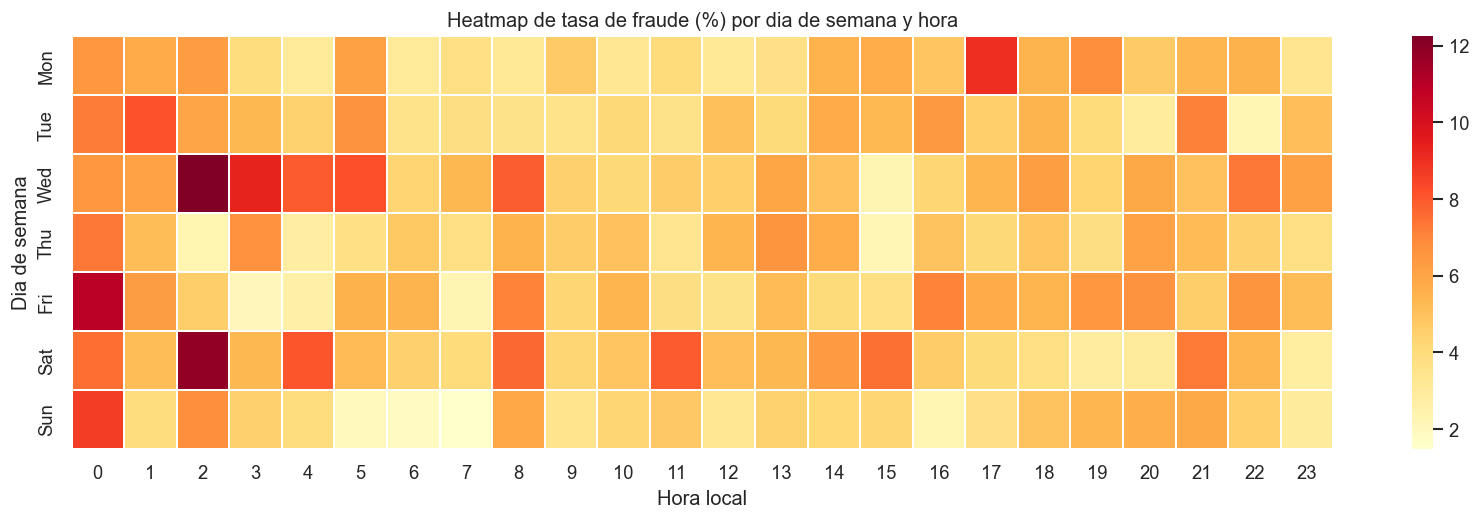

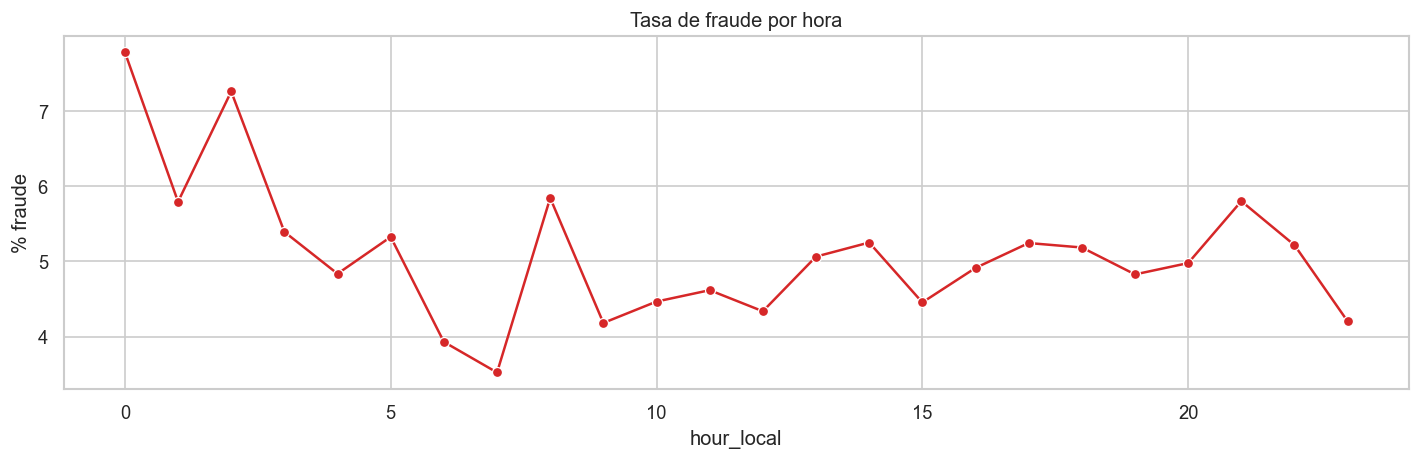

In [15]:
if {'hour_local', 'day_of_week'}.issubset(df.columns):
    tmp = df[['hour_local', 'day_of_week', target_col]].dropna().copy()
    tmp['hour_local'] = pd.to_numeric(tmp['hour_local'], errors='coerce')
    tmp = tmp.dropna(subset=['hour_local'])
    tmp['hour_local'] = tmp['hour_local'].astype(int)

    day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    tmp['day_of_week'] = tmp['day_of_week'].astype(str)
    tmp['day_of_week'] = pd.Categorical(tmp['day_of_week'], categories=day_order, ordered=True)

    heat = tmp.pivot_table(
        index='day_of_week',
        columns='hour_local',
        values=target_col,
        aggfunc='mean'
    ) * 100

    plt.figure(figsize=(14, 4.5))
    sns.heatmap(heat, cmap='YlOrRd', linewidths=0.1, linecolor='white')
    plt.title('Heatmap de tasa de fraude (%) por dia de semana y hora')
    plt.xlabel('Hora local')
    plt.ylabel('Dia de semana')
    plt.tight_layout()
    plt.show()

    by_hour = tmp.groupby('hour_local')[target_col].mean().reset_index(name='fraud_rate')
    by_hour['fraud_rate_pct'] = by_hour['fraud_rate'] * 100
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=by_hour, x='hour_local', y='fraud_rate_pct', marker='o', color='#d62728')
    plt.title('Tasa de fraude por hora')
    plt.ylabel('% fraude')
    plt.tight_layout()
    plt.show()

## 7) Concentracion de fraude por deciles (senales para reducir FP)

In [16]:
def decile_lift_table(frame, feature, target):
    t = frame[[feature, target]].dropna().copy()
    t['decile'] = pd.qcut(t[feature], q=10, duplicates='drop')
    out = t.groupby('decile')[target].agg(total='count', fraud_rate='mean', frauds='sum').reset_index()
    out['fraud_rate_pct'] = out['fraud_rate'] * 100
    out['share_data_pct'] = out['total'] / len(t) * 100
    return out.sort_values('fraud_rate', ascending=False)

decile_features = [c for c in ['amount_usd', 'distance_from_home_km', 'client_baseline_amount'] if c in df.columns]
for col in decile_features:
    print(f'\nDeciles - {col}')
    display(decile_lift_table(df, col, target_col).head(10).round(4))


Deciles - amount_usd


,decile,total,fraud_rate,frauds,fraud_rate_pct,share_data_pct
9,"(1196.54, 6731.9]",10000,0.1791,1791,17.9100,9.9997
8,"(632.878, 1196.54]",10001,0.0991,991,9.9090,10.0007
7,"(387.27, 632.878]",9999,0.0568,568,5.6806,9.9987
0,"(0.069, 35.27]",10002,0.0511,511,5.1090,10.0017
6,"(273.04, 387.27]",10000,0.0325,325,3.2500,9.9997
5,"(200.43, 273.04]",10000,0.0199,199,1.9900,9.9997
4,"(146.58, 200.43]",10000,0.0173,173,1.7300,9.9997
2,"(67.07, 102.82]",10000,0.0132,132,1.3200,9.9997
3,"(102.82, 146.58]",10001,0.0130,130,1.2999,10.0007
1,"(35.27, 67.07]",10000,0.0099,99,0.9900,9.9997



Deciles - distance_from_home_km


,decile,total,fraud_rate,frauds,fraud_rate_pct,share_data_pct
8,"(3435.0, 7716.0]",9902,0.0891,882,8.9073,9.9995
9,"(7716.0, 12000.0]",9901,0.0781,773,7.8073,9.9985
7,"(943.0, 3435.0]",9902,0.0660,654,6.6047,9.9995
6,"(118.0, 943.0]",9898,0.0619,613,6.1932,9.9955
5,"(21.1, 118.0]",9669,0.0349,337,3.4854,9.7642
0,"(-0.001, 4.2]",10012,0.0337,337,3.3660,10.1106
1,"(4.2, 8.4]",9880,0.0334,330,3.3401,9.9773
3,"(12.7, 16.9]",9952,0.0319,317,3.1853,10.0500
2,"(8.4, 12.7]",9972,0.0315,314,3.1488,10.0702
4,"(16.9, 21.1]",9937,0.0312,310,3.1197,10.0348



Deciles - client_baseline_amount


,decile,total,fraud_rate,frauds,fraud_rate_pct,share_data_pct
4,"(1399.8, 1568.34]",9997,0.0561,561,5.6117,9.9967
3,"(1200.46, 1399.8]",9999,0.0532,532,5.3205,9.9987
7,"(1952.69, 2134.5]",9994,0.0508,508,5.0830,9.9937
1,"(799.36, 998.14]",10010,0.0497,497,4.9650,10.0097
2,"(998.14, 1200.46]",9993,0.0478,478,4.7833,9.9927
5,"(1568.34, 1760.05]",10031,0.0473,474,4.7254,10.0307
0,"(599.999, 799.36]",10006,0.0471,471,4.7072,10.0057
6,"(1760.05, 1952.69]",9986,0.0471,470,4.7066,9.9857
8,"(2134.5, 2312.59]",9995,0.0468,468,4.6823,9.9947
9,"(2312.59, 2498.92]",9992,0.0460,460,4.6037,9.9917


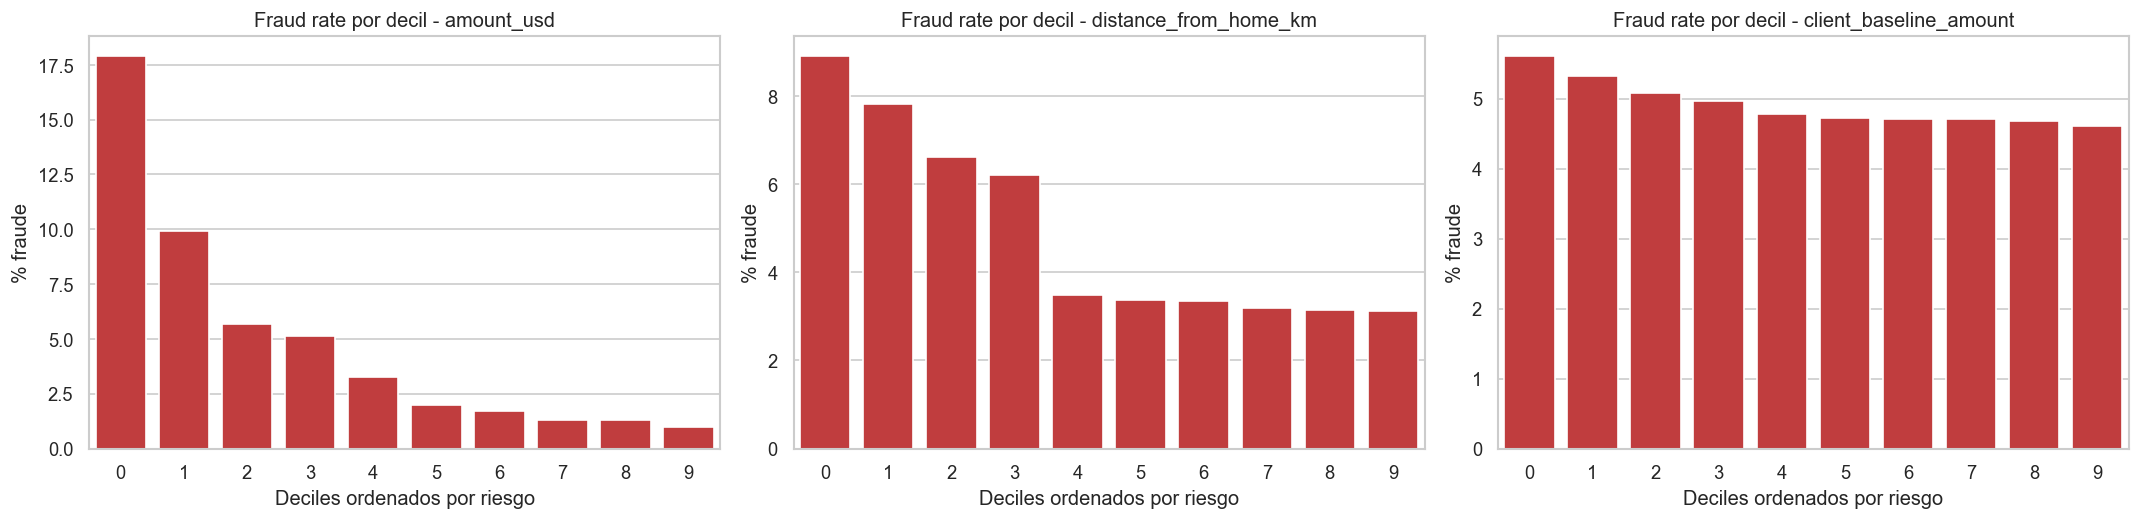

In [17]:
if decile_features:
    fig, axes = plt.subplots(1, len(decile_features), figsize=(6 * len(decile_features), 4.5))
    if len(decile_features) == 1:
        axes = [axes]

    for i, col in enumerate(decile_features):
        t = decile_lift_table(df, col, target_col).copy().reset_index(drop=True)
        sns.barplot(data=t, x=t.index.astype(str), y='fraud_rate_pct', color='#d62728', ax=axes[i])
        axes[i].set_title(f'Fraud rate por decil - {col}')
        axes[i].set_xlabel('Deciles ordenados por riesgo')
        axes[i].set_ylabel('% fraude')

    plt.tight_layout()
    plt.show()

Hallazgos clave orientados a reduccion de falsos positivos:

- El dataset mantiene desbalance severo (~19:1), por lo que accuracy no es util como metrica principal.
- Hay columnas con alto riesgo de leakage/post-evento (`DE39_response_code`, `approved`, `response_description`) que no deben usarse para entrenar el modelo predictivo.
- Variables de monto y distancia muestran separacion clara entre clases, utiles para discriminacion inicial.
- Ciertos codigos transaccionales y canales concentran mayor tasa de fraude; esto permite definir reglas/modelos con mejor precision.
- Los patrones por hora y dia sugieren ventanas de mayor riesgo, utiles para priorizar alertas sin sobredisparar falsos positivos.